In [1]:
import os
import sys

# to setup import paths add project root dirs to sys.path
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
from baseVR.base_functionality import init_import_paths
init_import_paths()

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# %matplotlib qt
%matplotlib widget

from analytics_processing import analytics
import analytics_processing.analytics_constants as C
from CustomLogger import CustomLogger as Logger

from dashsrc.plot_components.plot_wrappers.data_selection import group_filter_data

from analytics_processing.modality_loading import session_modality_from_nas
from analytics_processing.sessions_from_nas_parsing import sessionlist_fullfnames_from_args
from analytics_processing.sessions_from_nas_parsing import fullfnames2snames


In [3]:
output_dir = "./outputs/experimental/"
data = {}
nas_dir = C.device_paths()[0]
Logger().init_logger(None, None, logging_level="DEBUG")

In [4]:
animal_ids = [6]
paradigm_ids = [1100]
session_ids = None

In [54]:
session_dirs, _ = sessionlist_fullfnames_from_args(paradigm_ids, animal_ids, session_ids)
# for sd in session_dirs:
#     print(sd)
session_names = fullfnames2snames(session_dirs)
for sn in session_names:
    print(sn)

2025-10-30 13:04:24,105|DEBUG|27869|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Searching NAS for applicable sessions...
2025-10-30 13:04:24,171|DEBUG|27869|sessions_from_nas_parsing|get_sessionlist_fullfnames
	For paradigms [1100], animals [6], found 34 sessions.
2025-10-30 13:04:24,171|DEBUG|27869|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: [1100], animal_ids: [6], session_ids: None, from_date: None, to_date: None
	Merging 34 sessions



2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min
2024-11-14_16-40_rYL006_P1100_LinearTrackStop_21min
2024-11-15_15-48_rYL006_P1100_LinearTrackStop_35min
2024-11-20_17-46_rYL006_P1100_LinearTrackStop_22min
2024-11-21_17-22_rYL006_P1100_LinearTrackStop_25min
2024-11-22_16-01_rYL006_P1100_LinearTrackStop_24min
2024-11-25_16-25_rYL006_P1100_LinearTrackStop_18min
2024-11-26_16-39_rYL006_P1100_LinearTrackStop_25min
2024-11-27_16-11_rYL006_P1100_LinearTrackStop_31min
2024-11-28_17-41_rYL006_P1100_LinearTrackStop_30min
2024-11-29_17-21_rYL006_P1100_LinearTrackStop_28min
2024-12-02_16-09_rYL006_P1100_LinearTrackStop_28min
2024-12-03_16-23_rYL006_P1100_LinearTrackStop_30min
2024-12-04_18-06_rYL006_P1100_LinearTrackStop_30min
2024-12-06_16-49_rYL006_P1100_LinearTrackStop_25min
2024-12-09_17-45_rYL006_P1100_LinearTrackStop_26min
2024-12-10_17-20_rYL006_P1100_LinearTrackStop_30min
2024-12-11_17-42_rYL006_P1100_LinearTrackStop_30min
2024-12-12_16-13_rYL006_P1100_LinearTrackStop_26min
2024-12-13_1

In [55]:
fr_raw = analytics.get_analytics('FiringRate40msHz', session_names=session_names)
fr = fr_raw.drop("from_ephys_timestamp", axis=1)
fr.index = fr.index.droplevel((0,1,3, ))
fr.set_index('to_ephys_timestamp', append=True, inplace=True)
fr['global_t'] = np.arange(40_000, 40_000*len(fr)+1, 40_000)
fr.set_index('global_t', append=True, inplace=True)
fr.index = fr.index.rename(['session_id', 'session_t', 'global_t'])
fr

2025-10-30 13:04:25,151|DEBUG|27869|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2025-10-30 13:04:25,253|DEBUG|27869|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 34 sessions

2025-10-30 13:04:25,254|DEBUG|27869|analytics|get_analytics
	Processing FiringRate40msHz, (6, 1100, 0) 2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min.hdf5
/mnt/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min
2025-10-30 13:04:25,255|INFO|27869|analytics|get_analytics
	Analytic `FiringRate40msHz` not does not exist for (6, 1100, 0), compute first, or check for typo
2025-10-30 13:04:25,256|DEBUG|27869|analytics|get_analytics
	Processing FiringRate40msHz, (6, 1100, 1) 2024-11-14_16-40_rYL006_P1100_LinearTrackStop_21min.hdf5
/mnt/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_16-40_rYL00

Unit0001  Unit0002  Unit0003  Unit0004  \
session_id session_t  global_t                                              
1          40000      40000               0         0         0         0   
           80000      80000               0         0         0         0   
           120000     120000              0         0         0         0   
           160000     160000              0         0         0         0   
           200000     200000              0         0         0         0   
...                                     ...       ...       ...       ...   
33         4435960000 53320480000         0         0         0         0   
           4436000000 53320520000         0         0         0         0   
           4436040000 53320560000         0         0         0         0   
           4436080000 53320600000         0         0         0         0   
           4436120000 53320640000         0         0         0         0   

                                   Unit0005  Unit0006  Unit0007  Unit0008  \
session_id session_t  global_t                                              
1          40000      40000               0         0         0         0   
           80000      80000               0         0         0         0   
           120000     120000              0         0         0         0   
           160000     160000              0         0         0         0   
           200000     200000              0         0         0         0   
...                                     ...       ...       ...       ...   
33         4435960000 53320480000         0         0         0         0   
           4436000000 53320520000         0         0         0         0   
           4436040000 53320560000         0         0         0         0   
           4436080000 53320600000         0         0         0         0   
           4436120000 53320640000         0         0         0         0   

                                   Unit0009  Unit0010  ...  Unit0068  \
session_id session_t  global_t                         ...             
1          40000      40000               0         0  ...         0   
           80000      80000               0         0  ...         0   
           120000     120000              0         0  ...         0   
           160000     160000              0         0  ...         0   
           200000     200000              0         0  ...         0   
...                                     ...       ...  ...       ...   
33         4435960000 53320480000         0         0  ...        25   
           4436000000 53320520000         0         0  ...        25   
           4436040000 53320560000         0         0  ...        25   
           4436080000 53320600000         0         0  ...        25   
           4436120000 53320640000         0         0  ...         0   

                                   Unit0069  Unit0070  Unit0071  Unit0072  \
session_id session_t  global_t                                              
1          40000      40000               0         0         0         0   
           80000      80000               0         0         0         0   
           120000     120000              0         0         0         0   
           160000     160000              0         0         0         0   
           200000     200000              0         0         0         0   
...                                     ...       ...       ...       ...   
33         4435960000 53320480000         0         0        25         0   
           4436000000 53320520000         0         0        25         0   
           4436040000 53320560000        25         0        25         0   
           4436080000 53320600000         0         0         0         0   
           4436120000 53320640000         0        25         0         0   

                                   Unit0073  Unit0074  Unit0075  Unit0076  \
session_id sess

In [56]:
fr_raw = analytics.get_analytics('FiringRate40msHz', session_names=session_names)

behavior = analytics.get_analytics('BehaviorFramewise', session_names=session_names, columns=[
    "frame_ephys_timestamp",
    # action based
    "frame_velocity",
    "frame_acceleration",
    "frame_raw",
    "frame_yaw",
    "frame_pitch",
    "lick_count",
    
    # state based
    "frame_position",
    # "reward-removed_count",
    "reward-sound_count",
    "reward-valve-open_count",
])
behavior

2025-10-30 13:04:29,231|DEBUG|27869|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2025-10-30 13:04:29,339|DEBUG|27869|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 34 sessions

2025-10-30 13:04:29,340|DEBUG|27869|analytics|get_analytics
	Processing FiringRate40msHz, (6, 1100, 0) 2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min.hdf5
/mnt/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min
2025-10-30 13:04:29,341|INFO|27869|analytics|get_analytics
	Analytic `FiringRate40msHz` not does not exist for (6, 1100, 0), compute first, or check for typo
2025-10-30 13:04:29,342|DEBUG|27869|analytics|get_analytics
	Processing FiringRate40msHz, (6, 1100, 1) 2024-11-14_16-40_rYL006_P1100_LinearTrackStop_21min.hdf5
/mnt/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_16-40_rYL00

frame_ephys_timestamp  \
paradigm_id animal_id session_id entry_id                          
6           1100      0          0                          <NA>   
                                 1                          <NA>   
                                 2                          <NA>   
                                 3                          <NA>   
                                 4                          <NA>   
...                                                          ...   
                      33         265636               4435022300   
                                 265637               4435038950   
                                 265638               4435055650   
                                 265639               4435072300   
                                 265640               4435089000   

                                           frame_velocity  frame_acceleration  \
paradigm_id animal_id session_id entry_id                                       
6           1100      0          0                    0.0                 0.0   
                                 1                    0.0                 0.0   
                                 2                    0.0                 0.0   
                                 3                    0.0                 0.0   
                                 4                    0.0                 0.0   
...                                                   ...                 ...   
                      33         265636          4.857786           -0.671724   
                                 265637          4.301729           -0.579299   
                                 265638          3.699188           -0.299985   
                                 265639          3.701759            0.232348   
                                 265640          4.163885            0.462126   

                                           frame_raw  frame_yaw  frame_pitch  \
paradigm_id animal_id session_id entry_id                                      
6           1100      0          0              <NA>       <NA>         <NA>   
                                 1                 3          0           -1   
                                 2                 0          0           -2   
                                 3                -1          1           -2   
                                 4                 0         -1           -4   
...                                              ...        ...          ...   
                      33         265636           57         78            0   
                                 265637           48         87            0   
                                 265638           45        101            0   
                                 265639           35         96            0   
                                 265640           45        119            0   

                                           lick_count  frame_position  \
paradigm_id animal_id session_id entry_id                               
6           1100      0          0                0.0             0.0   
                                 1                0.0             0.0   
                                 2                0.0             0.0   
                                 3                0.0             0.0   
                                 4                0.0             0.0   
...                                               ...             ...   
                      33         265636           0.0     -166.791901   
                                 265637           0.0     -166.717804   
                                 265638           0.0     -166.648499   
                                 265639           0.0     -166.594498   
                                 265640           0.0     -166.525101   

                                           reward-sound_count  \
paradigm_id animal_id session_id entry_id       

In [57]:
def align_frame_to_ephys_bins(session_ephys, session_behavior):
    """
    Align frame data to ephys time bins for a given session.
    
    Parameters:
    -----------
    ephys_bins : pd.DataFrame
        DataFrame with from_ephys_timestamp and to_ephys_timestamp columns
    frame_data : pd.DataFrame
        DataFrame with frame_ephys_timestamp column
    session_id : int
        Session ID to process
        
    Returns:
    --------
    pd.DataFrame
        Frame data resampled to ephys time bins with added bin information
    """
    # Filter both datasets for the specified session
    
    # Create interval index for ephys bins
    ephys_intervals = pd.IntervalIndex.from_arrays(
        session_ephys['from_ephys_timestamp'],
        session_ephys['to_ephys_timestamp'],
        closed='right'
    )
    
    # Assign each frame to an ephys bin
    frame_bin_assignment = pd.cut(
        session_behavior['frame_ephys_timestamp'],
        bins=ephys_intervals,
        labels=np.arange(len(ephys_intervals))
    )
    
    # Add bin assignment back to frame data
    session_behavior = session_behavior.copy()
    session_behavior['ephys_bin_id'] = frame_bin_assignment
    
    # Group frames by ephys bins and aggregate
    grouped_data = session_behavior.groupby('ephys_bin_id').agg({
        "frame_velocity": 'mean',
        "frame_acceleration": 'mean',
        "frame_raw": 'mean',
        "frame_yaw": 'mean',
        "frame_pitch": 'mean',
        "lick_count": 'sum',
        
        # state based
        "frame_position": 'mean',
        # "reward-removed_count": 'sum',
        "reward-sound_count": 'sum',
        "reward-valve-open_count": 'sum',
    })
    
    # Add ephys bin timestamps
    grouped_data['bin_start'] = session_ephys['from_ephys_timestamp'].values
    grouped_data['bin_end'] = session_ephys['to_ephys_timestamp'].values
    
    return grouped_data

# Example usage:
# aligned_data = align_frame_to_ephys_bins(ephys_bins_df, frame_data_df, session_id=1)

In [58]:

s1_fr = fr_raw.xs(1, level='session_id')
print(s1_fr)
s1_beh = behavior.xs(1, level='session_id')
print(s1_beh)

o = align_frame_to_ephys_bins(s1_fr, s1_beh).dropna()
o


                                Unit0001  Unit0002  Unit0003  Unit0004  \
paradigm_id animal_id entry_id                                           
6           1100      0                0         0         0         0   
                      1                0         0         0         0   
                      2                0         0         0         0   
                      3                0         0         0         0   
                      4                0         0         0         0   
...                                  ...       ...       ...       ...   
                      32195            0         0         0         0   
                      32196            0         0         0         0   
                      32197            0         0         0         0   
                      32198            0         0         0         0   
                      32199            0         0         0         0   

                                Unit0

/tmp/ipykernel_27869/350417151.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = session_behavior.groupby('ephys_bin_id').agg({


,frame_velocity,frame_acceleration,frame_raw,frame_yaw,frame_pitch,lick_count,frame_position,reward-sound_count,reward-valve-open_count,bin_start,bin_end
ephys_bin_id,,,,,,,,,,,
"(1880000, 1920000]",0.0,0.0,163.0,-57.0,-462.0,0.0,0.0,0.0,0.0,1880000,1920000
"(1920000, 1960000]",0.0,0.0,150.0,-42.666667,-227.333333,0.0,0.0,0.0,0.0,1920000,1960000
"(1960000, 2000000]",0.0,0.0,187.0,-63.0,-158.0,0.0,0.0,0.0,0.0,1960000,2000000
"(2000000, 2040000]",0.0,0.0,235.0,-81.0,-123.0,0.0,0.0,0.0,0.0,2000000,2040000
"(2040000, 2080000]",0.0,0.0,314.0,-89.5,-91.0,0.0,0.0,0.0,0.0,2040000,2080000
...,...,...,...,...,...,...,...,...,...,...,...
"(1286800000, 1286840000]",0.0,-0.0,530.0,62.0,-126.5,0.0,262.434601,0.0,0.0,1286800000,1286840000
"(1286840000, 1286880000]",0.0,0.0,356.0,176.333333,-135.0,0.0,262.434601,0.0,0.0,1286840000,1286880000
"(1286880000, 1286920000]",-0.0,-0.0,373.0,259.0,-160.0,0.0,262.434601,0.0,0.0,1286880000,1286920000


In [7]:
session_t_start = fr.index[fr.index.get_level_values('session_t') == 40_000]
session_t_start

MultiIndex([( 1, 40000,       40000),
            ( 2, 40000,  1288040000),
            ( 3, 40000,  3431720000),
            ( 4, 40000,  4785080000),
            ( 6, 40000,  6337280000),
            ( 7, 40000,  7435640000),
            ( 9, 40000,  8964160000),
            (10, 40000, 10808920000),
            (11, 40000, 10928920000),
            (12, 40000, 12642240000),
            (13, 40000, 14446240000),
            (14, 40000, 16278040000),
            (15, 40000, 17816880000),
            (16, 40000, 19385920000),
            (17, 40000, 21242200000),
            (18, 40000, 23046200000),
            (19, 40000, 24659560000),
            (20, 40000, 26506040000),
            (21, 40000, 28320080000),
            (22, 40000, 30149040000),
            (23, 40000, 31989480000),
            (24, 40000, 33836440000),
            (25, 40000, 34016440000),
            (26, 40000, 34337520000),
            (27, 40000, 36865480000),
            (28, 40000, 39371160000),
            

/tmp/ipykernel_27869/995298829.py:114: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(


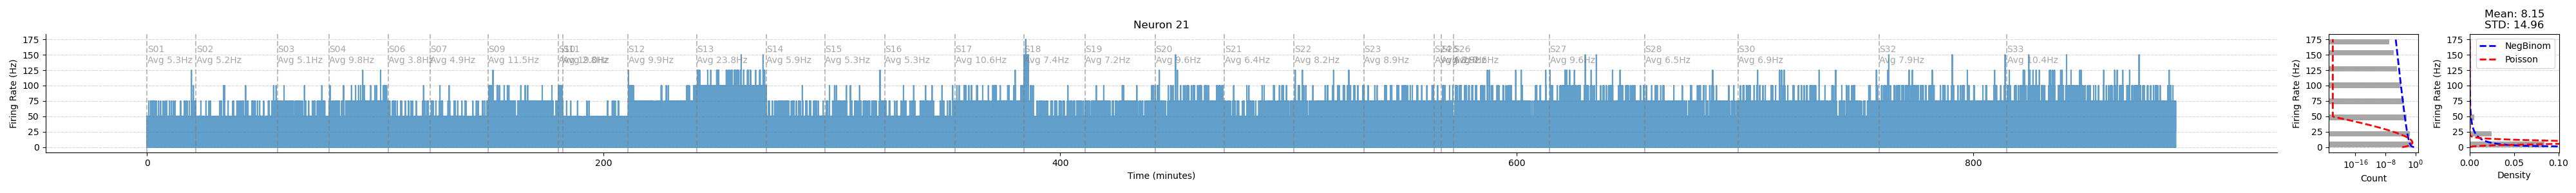

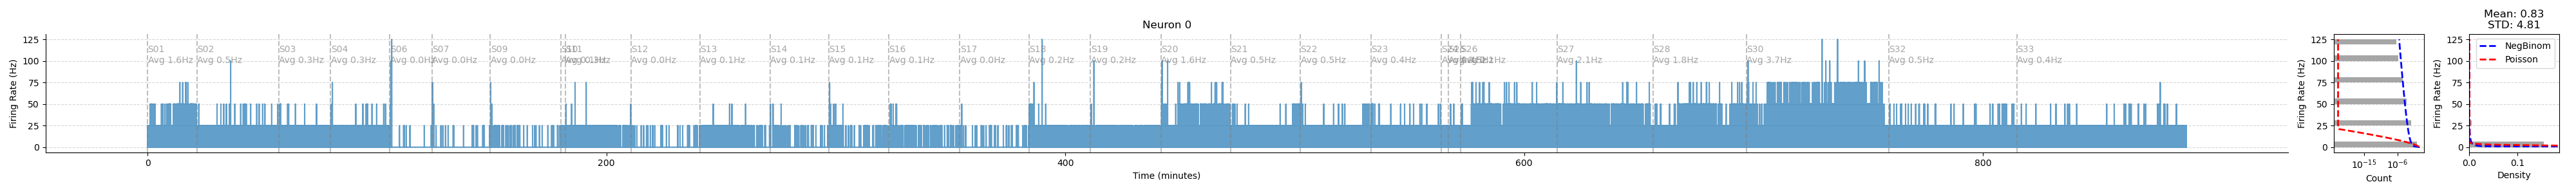

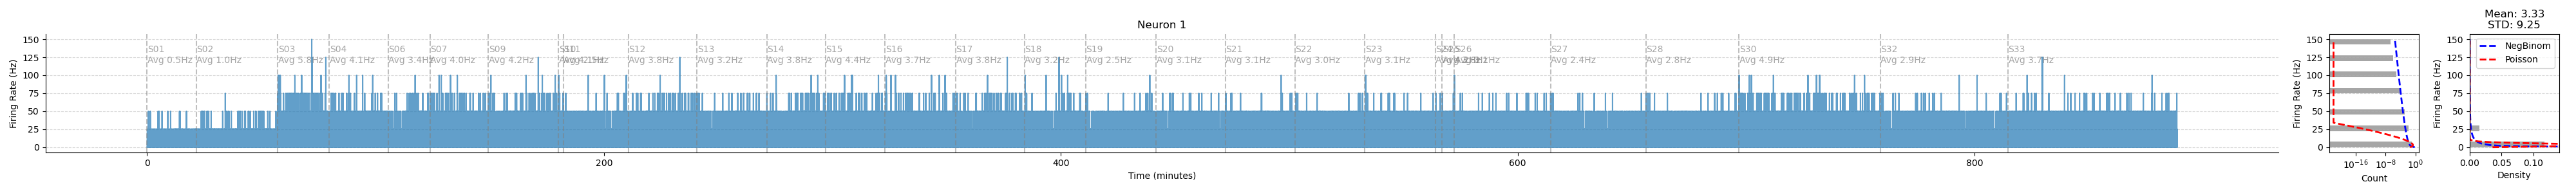

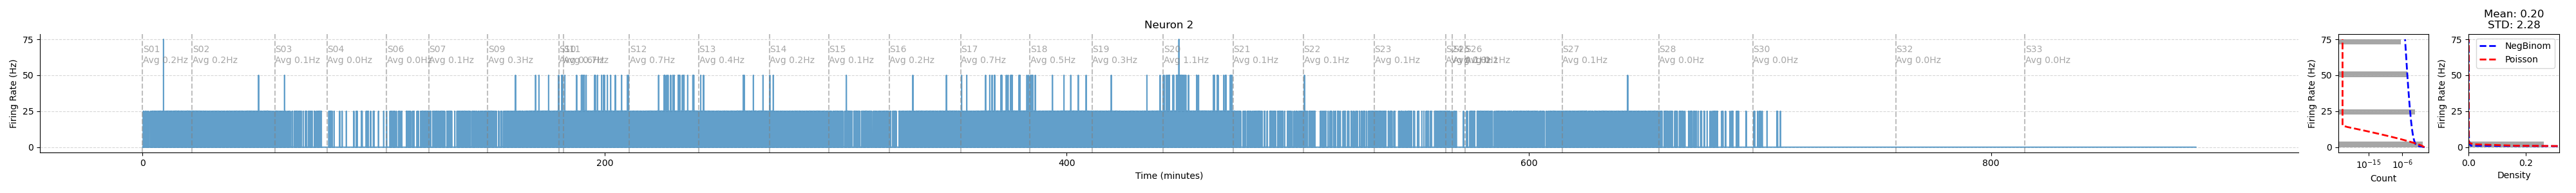

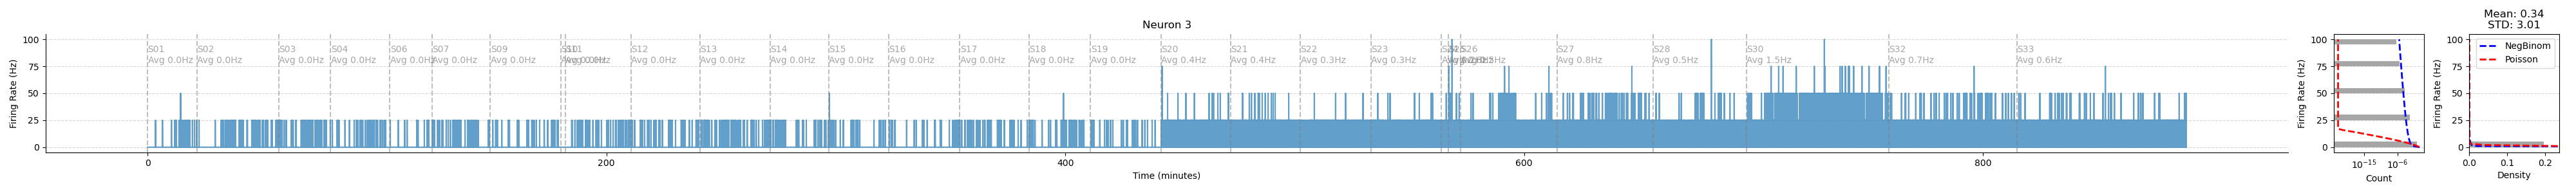

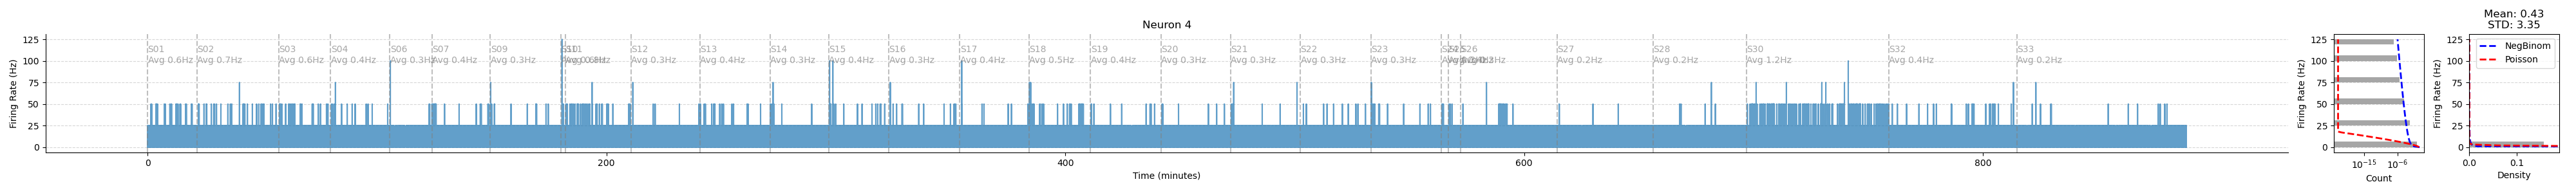

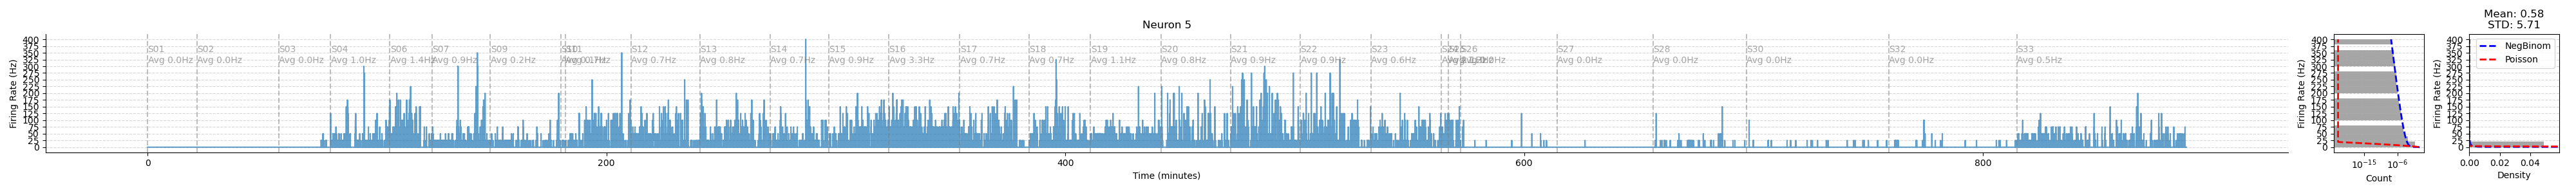

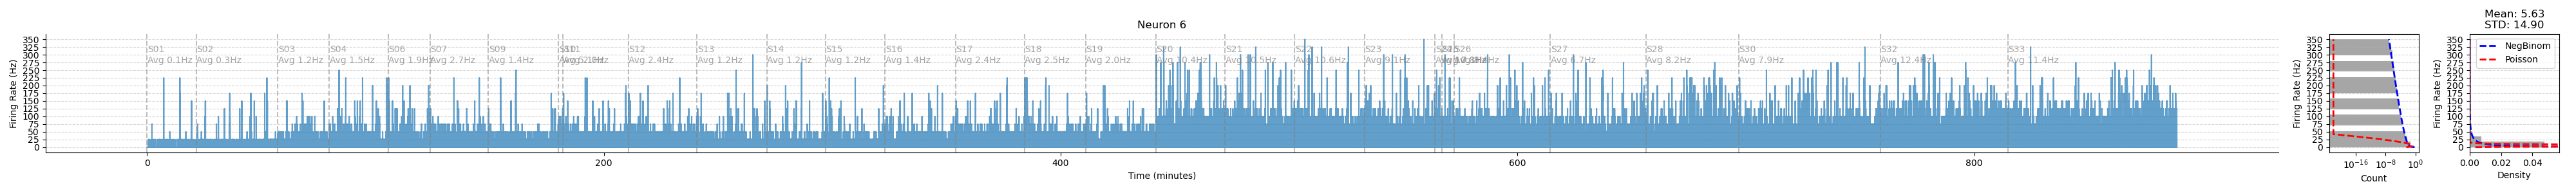

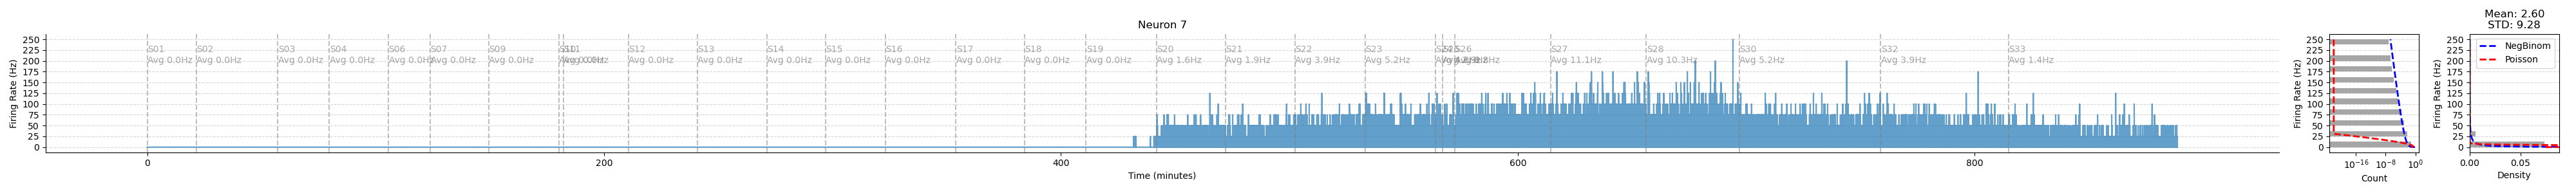

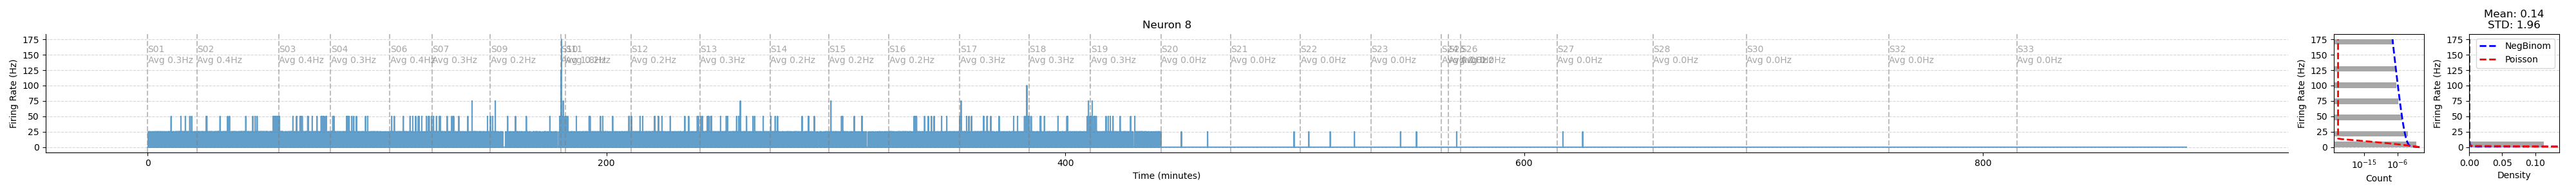

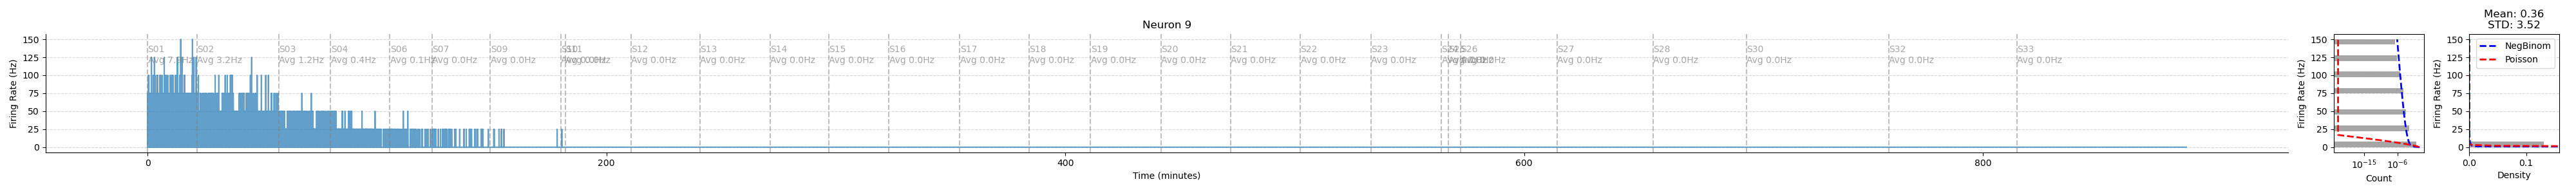

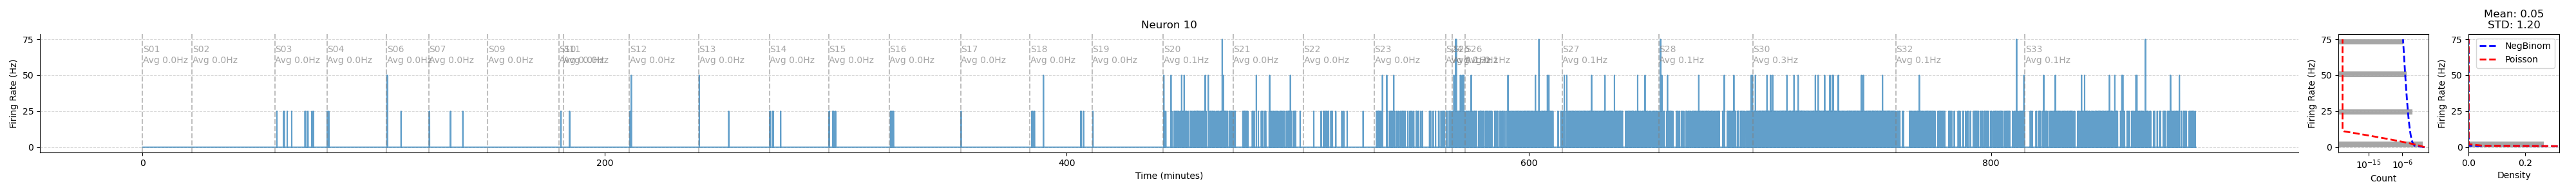

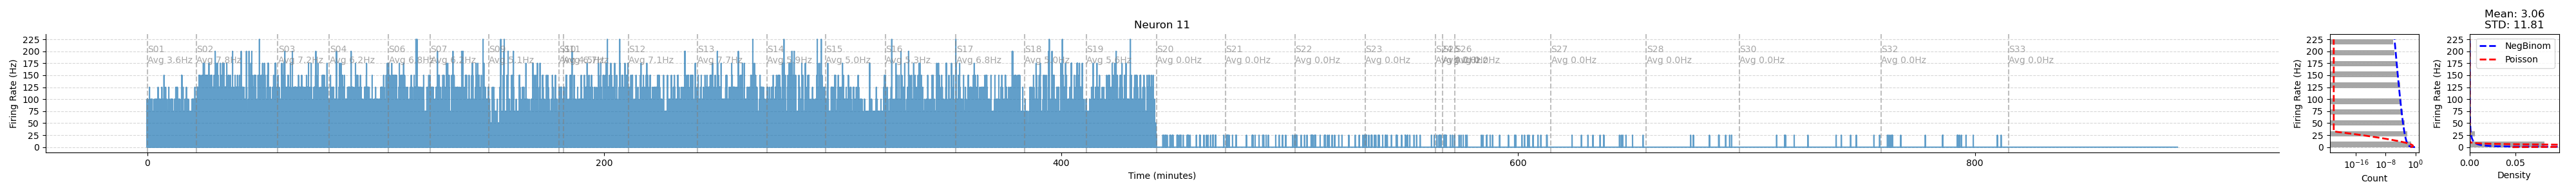

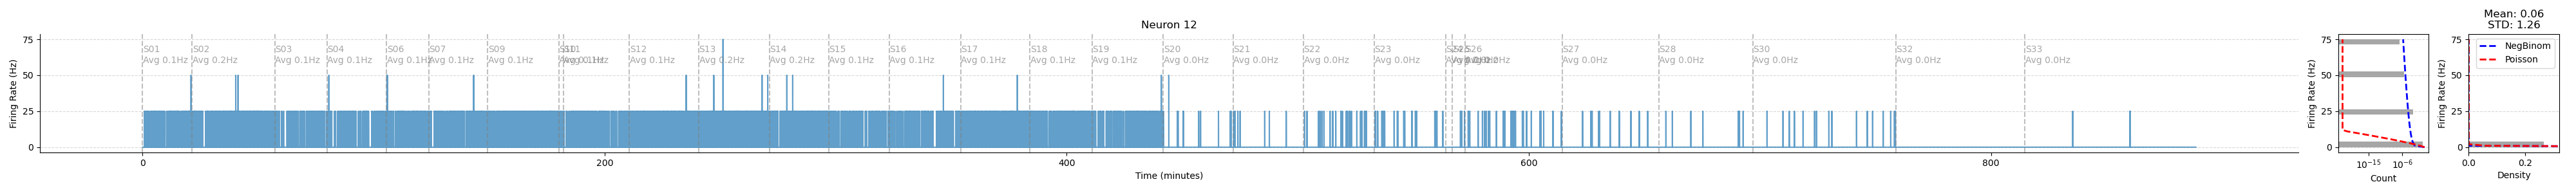

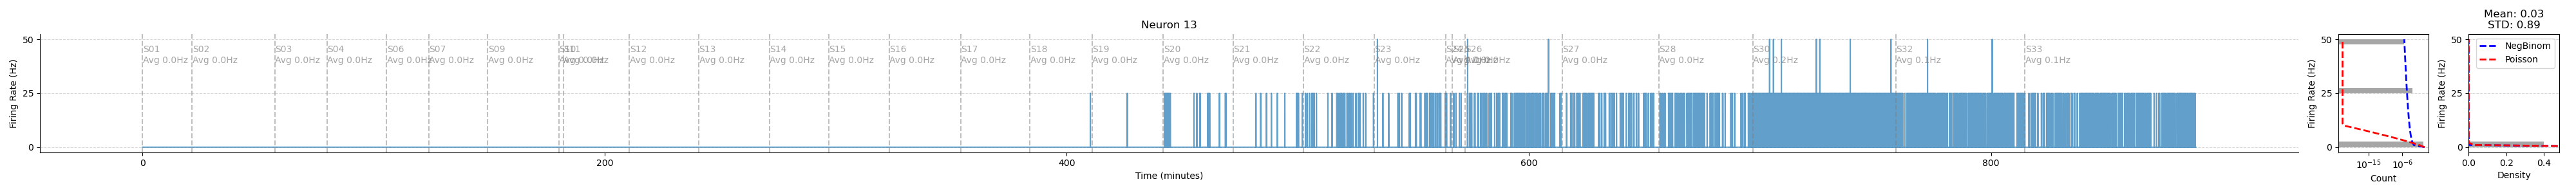

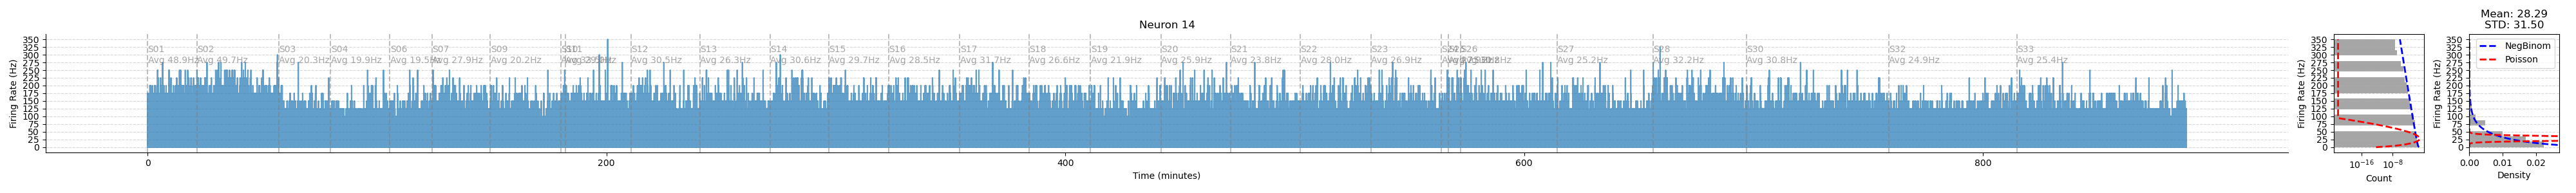

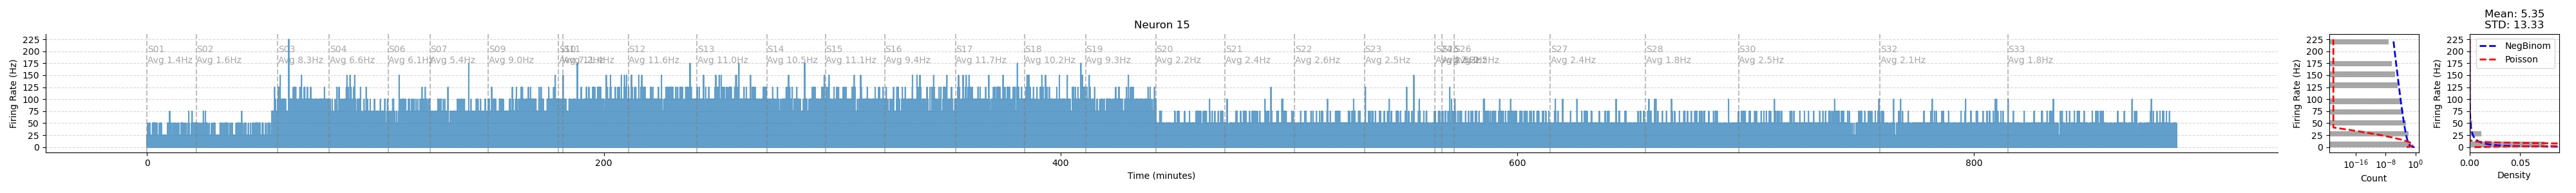

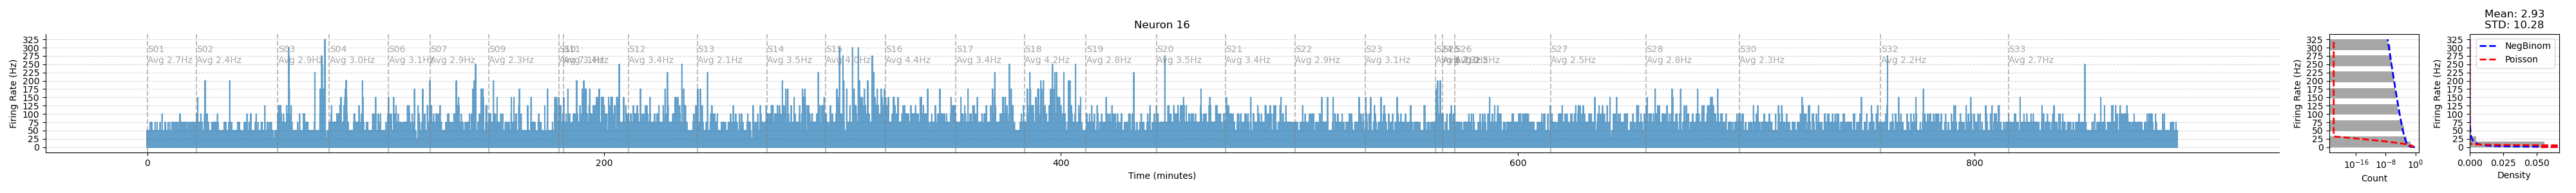

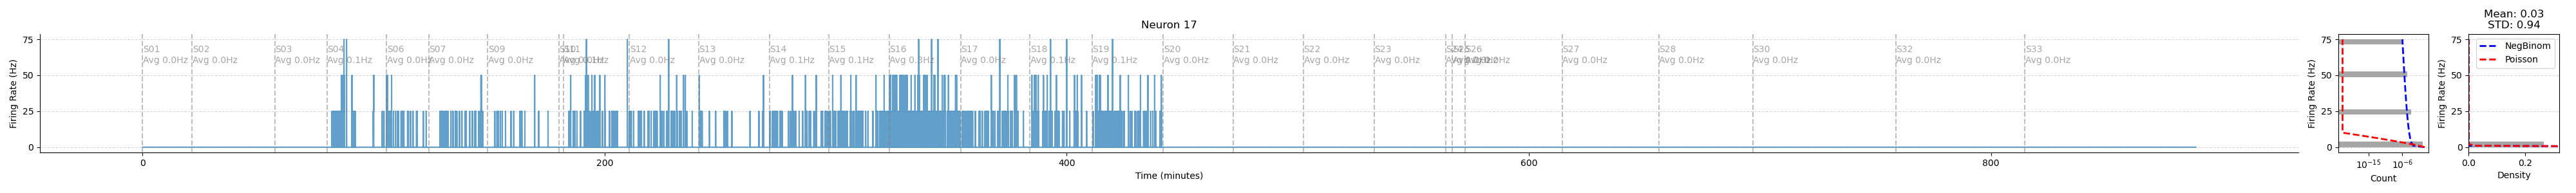

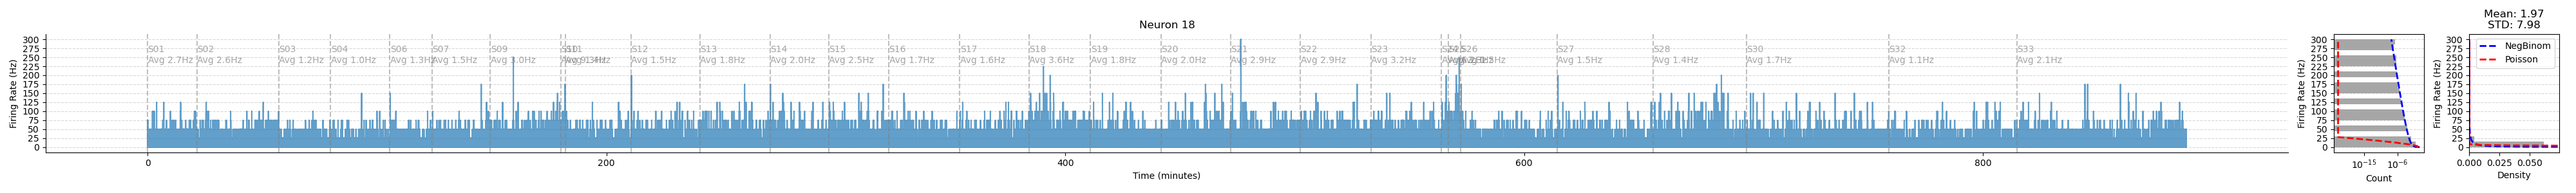

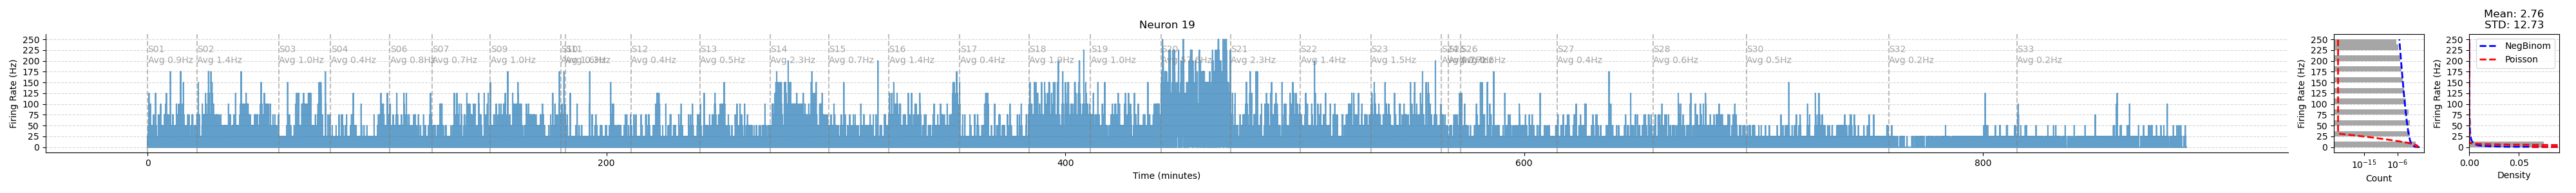

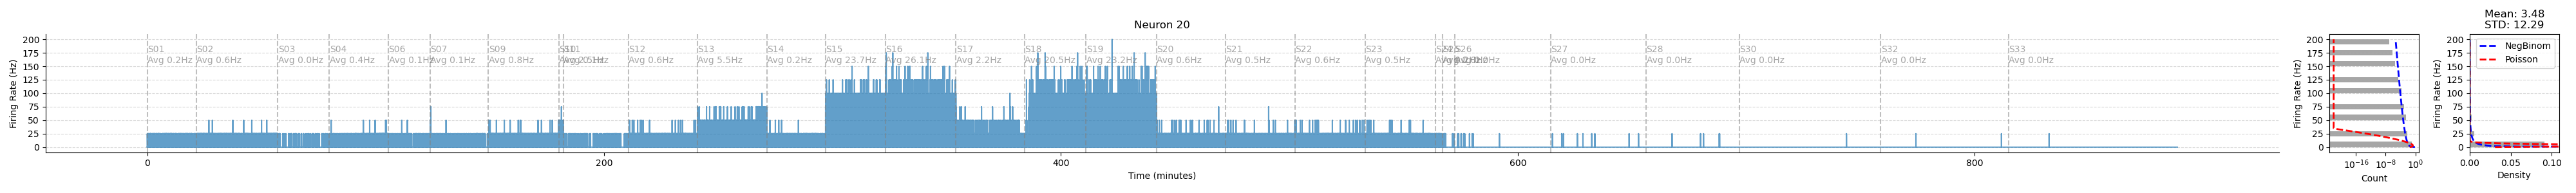

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy import stats


# ==============================================================
# === COMPUTATION UTILITIES ====================================
# ==============================================================

def compute_distribution_params(unit_hz):
    """
    Compute firing rate statistics and PMFs for Poisson and Negative Binomial.
    Returns dict with mean, std, variance, PMFs, etc.
    """
    m = unit_hz.mean()
    std = unit_hz.std()
    var = std ** 2

    # Convert firing rates to discrete counts
    discrete_counts = np.round(unit_hz.values).astype(int)
    discrete_counts = discrete_counts[discrete_counts >= 0]
    lam = discrete_counts.mean()

    # PMFs
    x = np.arange(0, max(10, discrete_counts.max()) + 1)
    pois_pmf = stats.poisson.pmf(x, lam)

    # Negative binomial params
    p = m / var if var > m else 0.999  # prevent division by zero
    r = m * p / (1 - p)
    nb_pmf = stats.nbinom.pmf(x, r, p)

    return {
        "mean": m,
        "std": std,
        "var": var,
        "lam": lam,
        "x": x,
        "pois_pmf": pois_pmf,
        "nb_pmf": nb_pmf,
    }


# ==============================================================
# === PLOTTING UTILITIES =======================================
# ==============================================================

def plot_firing_rate_trace(ax, unit_hz, session_t_start, fr_index, neuron_i):
    """Plot main firing rate trace with session demarcations."""
    ax.plot(fr_index.get_level_values('global_t') / (1e6 * 60), unit_hz, alpha=0.7)
    for i in range(len(session_t_start)):
        s_id, _, global_t_start = session_t_start[i]
        global_t_end = (
            session_t_start[i + 1][2]
            if i + 1 < len(session_t_start)
            else fr_index.get_level_values('global_t').max()
        )
        avg_fr = unit_hz[
            (fr_index.get_level_values('global_t') >= global_t_start)
            & (fr_index.get_level_values('global_t') < global_t_end)
        ].mean()
        s_str = f"S{s_id:02}\nAvg {avg_fr:.1f}Hz"
        ax.axvline(global_t_start / (1e6 * 60), color='gray', linestyle='--', alpha=0.5)
        ax.text(global_t_start / (1e6 * 60) + 0.1, ax.get_ylim()[1] * 0.9, s_str,
                verticalalignment='top', color='gray', alpha=0.7)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(f'Neuron {neuron_i}')
    ax.set_xlabel('Time (minutes)')
    ax.set_ylabel('Firing Rate (Hz)')
    ax.yaxis.set_major_locator(MultipleLocator(25))
    ax.grid(axis='y', linestyle='--', alpha=0.5)


def plot_histograms(ax1, ax2, unit_hz, x, nb_pmf, pois_pmf):
    """Plot histogram + Poisson and NegBinom fits."""
    # First histogram (log x-scale)
    ax1.hist(unit_hz, bins=20, orientation='horizontal', color='gray', alpha=0.7, density=True)
    ax1.plot(nb_pmf, x, 'b--', lw=2)
    ax1.plot(np.clip(pois_pmf, 1e-22, None), x, 'r--', lw=2)
    ax1.set_xscale('log')
    ax1.set_xlabel('Count')
    ax1.set_ylabel('Firing Rate (Hz)')
    ax1.yaxis.set_major_locator(MultipleLocator(25))
    ax1.grid(axis='y', linestyle='--', alpha=0.5)

    # Second histogram (linear x-scale)
    bins = ax2.hist(unit_hz, bins=20, orientation='horizontal', color='gray', alpha=0.7, density=True)[0]
    ax2.plot(nb_pmf, x, 'b--', lw=2, label='NegBinom')
    ax2.plot(pois_pmf, x, 'r--', lw=2, label='Poisson')
    ax2.set_xlabel('Density')
    ax2.set_ylabel('Firing Rate (Hz)')
    ax2.legend()
    ax2.yaxis.set_major_locator(MultipleLocator(25))
    ax2.set_xlim(0, np.max(bins) * 1.2)
    ax2.grid(axis='y', linestyle='--', alpha=0.5)


# ==============================================================
# === MAIN WRAPPER =============================================
# ==============================================================

def plot_neuron_summary(fr, session_t_start, neuron_indices=None):
    """
    For each neuron, plot firing rate trace and histogram with Poisson/NB fits.
    """
    plt.close('all')
    if neuron_indices is None:
        neuron_indices = range(fr.shape[1])

    for neuron_i in neuron_indices:
        fig, ax = plt.subplots(
            ncols=3, nrows=1, figsize=(40, 3), sharey=False,
            tight_layout=True, width_ratios=(25, 1, 1)
        )
        fig.subplots_adjust(left=0.05, right=0.95)

        unit_hz = fr.iloc[:, neuron_i]
        params = compute_distribution_params(unit_hz)

        plot_firing_rate_trace(ax[0], unit_hz, session_t_start, fr.index, neuron_i)
        plot_histograms(ax[1], ax[2], unit_hz, params["x"], params["nb_pmf"], params["pois_pmf"])

        # Display summary text
        m, std = params["mean"], params["std"]
        ax[2].set_title(f'Mean: {m:.2f}\nSTD: {std:.2f}')

        if neuron_i > 20:
            break

    plt.show()


# ==============================================================
# === EXAMPLE USAGE ============================================
# ==============================================================

# Example call (assuming `fr` and `session_t_start` are defined):
plot_neuron_summary(fr, session_t_start)
# or for a subset:
# plot_neuron_summary(fr, session_t_start, neuron_indices=range(5))


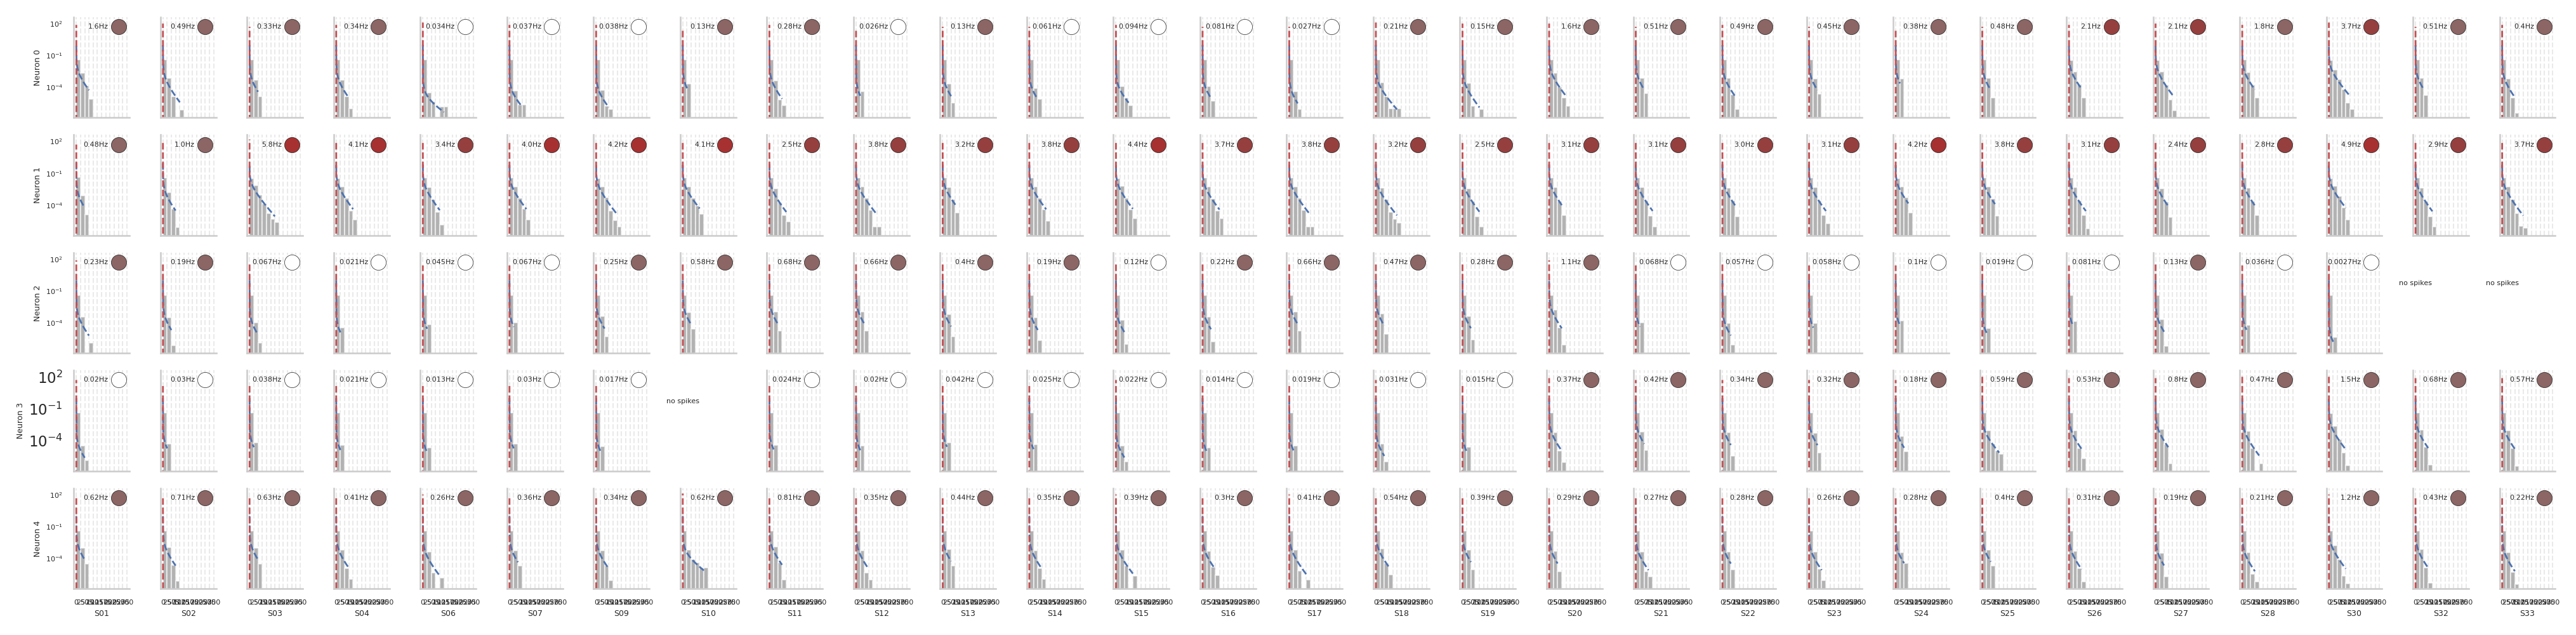

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from scipy import stats

# ==============================================================
# === COMPUTATION UTILITIES ====================================
# ==============================================================
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, Normalize

def fr_colors(maxval=32):
    """Return (cmap, norm) for firing-rate heatmaps.

    - maxval: maximum FR value (same scale used when building stops).
    - cmap: matplotlib colormap (continuous, 256 colors).
    - norm: Normalize(vmin=0, vmax=maxval) to pass to imshow/Scatter/Colorbar.
    """
    eps = 1e-6
    stops = [
        (0, '#ffffff'),
        ((0 + eps) / maxval, "#e8e8e8"),
        (0.1 / maxval, "#e8e8e8"),
        ((0.1 + eps) / maxval, "#8C6565"),
        (1.0 / maxval, "#8C6565"),
        ((1 + eps) / maxval, "#8C6565"),
        (2.0 / maxval, "#8C6565"),
        ((2 + eps) / maxval, "#963F3F"),
        (4.0 / maxval, "#963F3F"),
        ((4 + eps) / maxval, "#A73131"),
        (8.0 / maxval, "#A73131"),
        ((8 + eps) / maxval, "#D1552C"),
        (16.0 / maxval, "#D1552C"),
        ((16 + eps) / maxval, "#D1922C"),
        (32.0 / maxval, "#D1922C"),
    ]

    # defensive: ensure positions are in [0,1] and sorted
    stops = [(min(max(float(p), 0.0), 1.0), c) for p, c in stops]
    stops = sorted(stops, key=lambda t: t[0])

    # build a continuous colormap from the stop list
    cmap = LinearSegmentedColormap.from_list("fr_cmap", stops, N=256)

    # normalization maps data in [0, maxval] to [0,1] for the colormap
    norm = Normalize(vmin=0.0, vmax=float(maxval))
    return cmap, norm

def compute_distribution_params(unit_hz):
    """Compute firing rate statistics and PMFs for Poisson and Negative Binomial."""
    m = unit_hz.mean()
    std = unit_hz.std()
    var = std ** 2

    # Convert firing rates to discrete counts
    discrete_counts = np.round(unit_hz.values).astype(int)
    discrete_counts = discrete_counts[discrete_counts >= 0]
    lam = discrete_counts.mean()

    # PMFs
    x = np.arange(0, max(10, discrete_counts.max()) + 1)
    pois_pmf = stats.poisson.pmf(x, lam)

    # Negative binomial params
    p = m / var if var > m else 0.999  # prevent division by zero
    r = m * p / (1 - p)
    nb_pmf = stats.nbinom.pmf(x, r, p)

    return {
        "mean": m,
        "std": std,
        "x": x,
        "pois_pmf": pois_pmf,
        "nb_pmf": nb_pmf,
    }

# ==============================================================
# === GRID PLOTTING ============================================
# ==============================================================

def plot_neuron_session_histograms(fr, session_t_start, neuron_indices=None, n_bins=10):
    """
    Plot log(count histograms) for each neuron (rows) and session (columns).
    Each subplot shows histogram of log firing rates and mean/std in title.
    """
    if neuron_indices is None:
        neuron_indices = range(fr.shape[1])
    
    session_names = [f"S{s_id:02}" for s_id, _, _ in session_t_start]
    n_sessions = len(session_names)
    n_neurons = len(neuron_indices)

    fig, axes = plt.subplots(
        nrows=n_neurons, ncols=n_sessions,
        figsize=(1.4 * n_sessions, 2 * n_neurons),
        sharex=True, sharey=True
    )
    
    cmap, norm = fr_colors(maxval=32)
    
    # fig.colorbar(im, ax=ax, label='Firing rate (Hz)')

    # Ensure 2D array of axes
    if n_neurons == 1:
        axes = np.expand_dims(axes, 0)
    if n_sessions == 1:
        axes = np.expand_dims(axes, 1)

    fr_index = fr.index.get_level_values('global_t')

    # Compute start-end time of each session
    session_boundaries = []
    for i, (s_id, _, global_t_start) in enumerate(session_t_start):
        global_t_end = (
            session_t_start[i + 1][2]
            if i + 1 < len(session_t_start)
            else fr_index.max()
        )
        session_boundaries.append((s_id, global_t_start, global_t_end))

    # Iterate neurons × sessions
    for row, neuron_i in enumerate(neuron_indices):
        for col, (s_id, t_start, t_end) in enumerate(session_boundaries):
            ax = axes[row, col]
            unit_hz = fr.iloc[:, neuron_i]
            session_mask = (fr_index >= t_start) & (fr_index < t_end)
            session_data = unit_hz[session_mask]

            if np.all(session_data == 0):
                ax.text(0.5, 0.5, "no spikes", ha='center', va='center', fontsize=8)
                # turn off spines
                [ax.spines[side].set_visible(False) for side in ['top', 'right', 'left', 'bottom']]
                ax.set_xticks([]); ax.set_yticks([])
                # axis off
                ax.axis('off')
                continue

            params = compute_distribution_params(session_data)

            x = params["x"]
            nb_pmf = params["nb_pmf"]
            pois_pmf = params["pois_pmf"]
            ax.plot(x, nb_pmf, 'b--', lw=2, label='NegBinom')
            ax.plot(np.clip(pois_pmf, 1e-22, None), x, 'r--', lw=2)

            bin_edges = np.arange(0, 301, 25)  # 0–300 Hz in 25 Hz steps
            ax.hist(session_data, bins=bin_edges, color='gray', alpha=0.6, density=True)

            m, std = session_data.mean(), session_data.std()
            # ax.set_title(f"{m:.2f} ± {std:.2f}", fontsize=8)

            if row == n_neurons - 1:
                ax.set_xlabel(session_names[col], fontsize=9)
            if col == 0:
                ax.set_ylabel(f"Neuron {neuron_i}", fontsize=9)
            
            # draw a dot for firing rate
            # get max min x y values
            x_corner, y_corner = 250, 50
            ax.scatter([x_corner], [y_corner], color=cmap(norm(m)), s=300, 
                       edgecolor='k', linewidth=.5, zorder=3)
            ax.text(x_corner-60, y_corner, f"{m:.2}Hz", ha='right', va='center',
                    fontsize=8)
            
            sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
            
            # add thin vertical lines every 100, 200, 300 Hz
            # [ax.axvline(x, linestyle='-', linewidth=.5, color='k', alpha=.2) 
            #  for x in (100,200,300)]
            
            # set ticks at the 25 Hz grid and format as integer labels
            ax.xaxis.set_major_locator(MultipleLocator(25))
            ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
            plt.setp(ax.xaxis.get_ticklabels(), rotation=0, fontsize=8)
            plt.setp(ax.yaxis.get_ticklabels(), rotation=0, fontsize=8)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(axis='x', linestyle='--', alpha=0.4)
            ax.grid(False, axis='y')
            ax.set_yscale('log')
            
            

    plt.tight_layout()
    # fig.colorbar(sm, ax=ax, label='Firing rate (Hz)')

# Example usage (unchanged)
# set of 5 neurons 
plt.close("all")
for neuron_i in range(0,5, 5):
    plot_neuron_session_histograms(fr, session_t_start, neuron_indices=range(neuron_i,neuron_i+5))
    plt.show()  

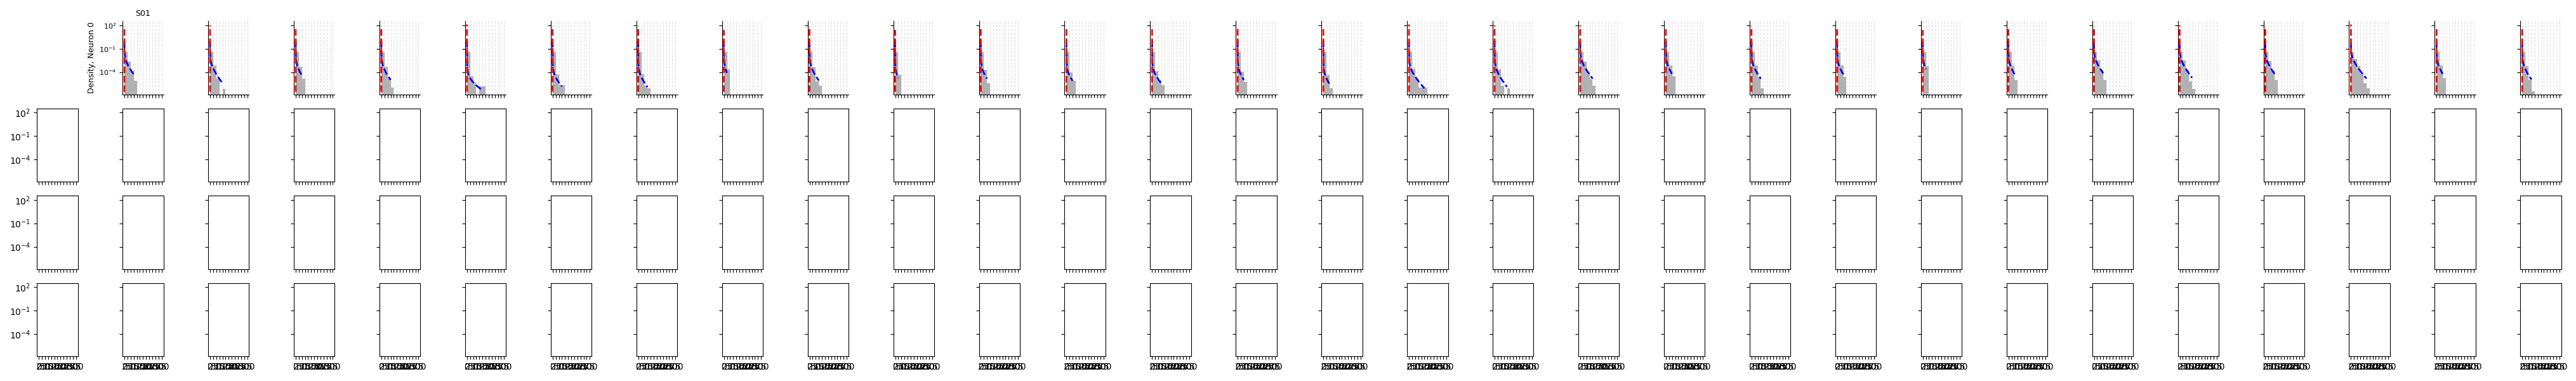

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from scipy import stats

# ==============================================================
# === COMPUTATION UTILITIES ====================================
# ==============================================================
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, Normalize

def compute_distribution_params(unit_hz):
    """Compute firing rate statistics and PMFs for Poisson and Negative Binomial."""
    m = unit_hz.mean()
    std = unit_hz.std()
    var = std ** 2

    # Convert firing rates to discrete counts
    discrete_counts = np.round(unit_hz.values).astype(int)
    discrete_counts = discrete_counts[discrete_counts >= 0]
    lam = discrete_counts.mean()

    # PMFs
    x = np.arange(0, max(10, discrete_counts.max()) + 1)
    pois_pmf = stats.poisson.pmf(x, lam)

    # Negative binomial params
    p = m / var if var > m else 0.999  # prevent division by zero
    r = m * p / (1 - p)
    nb_pmf = stats.nbinom.pmf(x, r, p)

    return {
        "mean": m,
        "std": std,
        "x": x,
        "pois_pmf": pois_pmf,
        "nb_pmf": nb_pmf,
    }

# ==============================================================
# === GRID PLOTTING ============================================
# ==============================================================

def plot_neuron_session_histograms(fr, session_t_start, neuron_i=0, n_bins=10):    
    session_names = [f"S{s_id:02}" for s_id, _, _ in session_t_start]
    n_sessions = len(session_names)
    n_regressers = 3

    fig, axes = plt.subplots(
        nrows=n_regressers+1, ncols=n_sessions+1,
        figsize=(1.4 * n_sessions, 2 * n_regressers),
        sharex=True, sharey=True
    )
    axes[0,0].axis("off")
    
    # cmap, norm = fr_colors(maxval=32)
    
    # fig.colorbar(im, ax=ax, label='Firing rate (Hz)')

    # Ensure 2D array of axes
    # if n_neurons == 1:
    #     axes = np.expand_dims(axes, 0)
    # if n_sessions == 1:
    #     axes = np.expand_dims(axes, 1)

    fr_index = fr.index.get_level_values('global_t')

    # Compute start-end time of each session
    session_boundaries = []
    for i, (s_id, _, global_t_start) in enumerate(session_t_start):
        global_t_end = (
            session_t_start[i + 1][2]
            if i + 1 < len(session_t_start)
            else fr_index.max()
        )
        session_boundaries.append((s_id, global_t_start, global_t_end))

    # Iterate neurons × sessions
    # for row, behavior_regr in enumerate(range(n_regressers)):
    
    # top row neuron marginal hist
    row = 0
    for col, (s_id, t_start, t_end) in enumerate(session_boundaries):
        ax = axes[row, col+1]
        unit_hz = fr.iloc[:, neuron_i]
        session_mask = (fr_index >= t_start) & (fr_index < t_end)
        session_data = unit_hz[session_mask]

        if np.all(session_data == 0):
            ax.text(0.5, 0.5, "no spikes", ha='center', va='center', fontsize=8)
            # turn off spines
            [ax.spines[side].set_visible(False) for side in ['top', 'right', 'left', 'bottom']]
            ax.set_xticks([]); ax.set_yticks([])
            # axis off
            ax.axis('off')
            continue

        params = compute_distribution_params(session_data)

        x = params["x"]
        nb_pmf = params["nb_pmf"]
        pois_pmf = params["pois_pmf"]
        ax.plot(x, nb_pmf, 'b--', lw=2, label='NegBinom')
        ax.plot(np.clip(pois_pmf, 1e-22, None), x, 'r--', lw=2)

        bin_edges = np.arange(0, 301, 25)  # 0–300 Hz in 25 Hz steps
        ax.hist(session_data, bins=bin_edges, color='gray', alpha=0.6, density=True)

        m, std = session_data.mean(), session_data.std()
        # ax.set_title(f"{m:.2f} ± {std:.2f}", fontsize=8)

        if col == 0:
            ax.set_ylabel(f"Density, Neuron {neuron_i}", fontsize=9)
            ax.tick_params(left=True, labelleft=True)
        ax.set_title(session_names[col], fontsize=9)
        
        # # draw a dot for firing rate
        # x_corner, y_corner = 250, 50
        # ax.scatter([x_corner], [y_corner], color=cmap(norm(m)), s=300, 
        #            edgecolor='k', linewidth=.5, zorder=3)
        # ax.text(x_corner-60, y_corner, f"{m:.2}Hz", ha='right', va='center',
        #         fontsize=8)
        
        # sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
        
        # add thin vertical lines every 100, 200, 300 Hz
        # [ax.axvline(x, linestyle='-', linewidth=.5, color='k', alpha=.2) 
        #  for x in (100,200,300)]
        
        # set ticks at the 25 Hz grid and format as integer labels
        ax.xaxis.set_major_locator(MultipleLocator(25))
        ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
        plt.setp(ax.xaxis.get_ticklabels(), rotation=0, fontsize=8)
        plt.setp(ax.yaxis.get_ticklabels(), rotation=0, fontsize=8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='x', linestyle='--', alpha=0.4)
        ax.grid(False, axis='y')
        ax.set_yscale('log')
            
            

    plt.tight_layout()
    # fig.colorbar(sm, ax=ax, label='Firing rate (Hz)')

# Example usage (unchanged)
# set of 5 neurons 
plt.close("all")
for neuron_i in range(0,1, 1):
    plot_neuron_session_histograms(fr, session_t_start, neuron_i=neuron_i)
    plt.show()  

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import nbinom

sns.set(style="whitegrid", context="talk")

# ==============================================================
# === SIMULATE DATA ============================================
# ==============================================================

np.random.seed(42)
n = 200

# Predictive regressor X1: correlated with rate
X1 = np.linspace(-2, 2, n)
# Irrelevant regressor X2: random noise
X2 = np.random.randn(n)

# True model parameters for X1
beta0, beta1 = 1.0, 0.8

# Mean firing rate (Poisson rate λ or mean of NegBin)
mu_true = np.exp(beta0 + beta1 * X1)

# Dispersion parameter for negative binomial
r = 5.0  # larger r → closer to Poisson
p = r / (r + mu_true)

# Draw negative binomial counts
Y = nbinom(n=r, p=p).rvs()

# ==============================================================
# === FIT SIMPLE MODELS ========================================
# ==============================================================

# Fit 1: model Y ~ X1 (predictive)
X1_design = np.vstack([np.ones(n), X1]).T
beta_hat1, _, _, _ = np.linalg.lstsq(X1_design, np.log(Y + 1e-6), rcond=None)
mu_hat1 = np.exp(X1_design @ beta_hat1)

# Fit 2: model Y ~ X2 (irrelevant)
X2_design = np.vstack([np.ones(n), X2]).T
beta_hat2, _, _, _ = np.linalg.lstsq(X2_design, np.log(Y + 1e-6), rcond=None)
mu_hat2 = np.exp(X2_design @ beta_hat2)

# Compute residuals
resid1 = Y - mu_hat1
resid2 = Y - mu_hat2

# ==============================================================
# === PLOTTING FUNCTION ========================================
# ==============================================================

def plot_joint(X, Y, mu_hat, resid, title):
    df = pd.DataFrame({"X": X, "Y": Y, "mu": mu_hat, "resid": resid})

    g = sns.jointplot(data=df, x="X", y="Y", kind="scatter", height=6)
    ax = g.ax_joint

    # Plot fitted mean curve
    X_sorted = np.linspace(X.min(), X.max(), 200)
    mu_sorted = np.exp(np.polyval(np.polyfit(X, np.log(mu_hat + 1e-6), 1), X_sorted))
    ax.plot(X_sorted, mu_sorted, color="red", lw=2.5, label="Fitted mean")

    # Residuals as vertical lines
    for i in range(0, len(X), 10):  # every 10th point for clarity
        ax.plot([X[i], X[i]], [mu_hat[i], Y[i]], color="gray", alpha=0.6)

    ax.legend()
    ax.set_title(title)
    plt.show()


# ==============================================================
# === VISUALIZE ================================================
# ==============================================================

plot_joint(X1, Y, mu_hat1, resid1, "Predictive regressor X1 → Negative Binomial firing rate")
plot_joint(X2, Y, mu_hat2, resid2, "Irrelevant regressor X2 → No predictive power")


In [ ]:

# do the same for PCA and ensembles



In [ ]:
plt.close('all')

In [ ]:
step_us = 60 * 1e6  # 1 minute in microseconds
window_size_us = 3 * step_us  # 3 minutes
end_time = int(fr.index.get_level_values('global_t').max()) - int(window_size_us)

all_sess_eigenvecs = []
for start_time in range(0, end_time, int(step_us)):
    end_time = start_time + window_size_us
    # print("From ", start_time, " to ", end_time)
    # continue
    window_data = fr_z.xs(slice(start_time, end_time), level='global_t')
    s_id = window_data.index.get_level_values('session_id').unique()[0]
    
    # print(window_data.index)
    window_Z = window_data.values.T  # transpose to have neurons in rows, time bins in columns
    const_neuron_indices = np.where((window_Z.var(axis=1)) > 1e-3)

    # compute correlation matrix
    corr_matrix = np.corrcoef(window_Z[const_neuron_indices])
    eigenvals, eigenvecs = np.linalg.eigh(corr_matrix)
    
    # Sort eigenvalues in descending order
    idx = np.argsort(eigenvals)[::-1]
    eigenvals = eigenvals[idx]
    eigenvecs = eigenvecs[:, idx]
    
    # plt.figure()
    # plt.imshow(eigenvecs, aspect='auto', cmap='bwr', vmin=-1, vmax=1)
    # plt.show()
    
    full_eigenvecs = np.zeros((fr.shape[1], fr.shape[1]))
    # insert eigenvecs back to full size
    idx = const_neuron_indices[0]
    # this is a square operation, also introduces unwanted columns
    full_eigenvecs[np.ix_(idx, idx)] = eigenvecs
    # get rid of full 0 eigenvec columns, we only want the rows in original dim
    full_eigenvecs = full_eigenvecs[:, (full_eigenvecs != 0).any(axis=0)]
    # limit to 80 perc varianace explained
    eigenval_sum = np.sum(eigenvals)
    expl_var = eigenvals / eigenval_sum
    expl_var_cum = np.cumsum(expl_var)
    n_components_80 = np.where(expl_var_cum >= 0.8)[0][0] + 1
    # print("Number of components to explain 80% variance: ", n_components_80)
    full_eigenvecs = full_eigenvecs[:, :n_components_80].astype(np.float32)

    print(full_eigenvecs.T.shape)
    all_sess_eigenvecs.append(pd.DataFrame(full_eigenvecs.T, index=pd.MultiIndex.from_product(
        [[s_id], [start_time], np.arange(full_eigenvecs.shape[1])], names=['session_id', 'start_time', 'component_index'])))

    # plt.figure()
    # plt.imshow(full_eigenvecs, aspect='auto', cmap='bwr', vmin=-1, vmax=1)
    # plt.show()

    # print(full_eigenvecs.shape)
    # print(start_time / end_time)
    # print(full_eigenvecs.dtype)
    
    # if start_time > 100000000:
    #     break


# corr_matrix = np.corrcoef(Z)
# eigenvals, eigenvecs = np.linalg.eigh(corr_matrix)
    
# # Sort eigenvalues in descending order
# idx = np.argsort(eigenvals)[::-1]
# eigenvals = eigenvals[idx]
# eigenvecs = eigenvecs[:, idx]
# # eigenvecs
# eigenval_sum = np.sum(eigenvals)
# expl_var = eigenvals / eigenval_sum
# expl_var_cum = np.cumsum(expl_var)
# expl_var_cum

all_sess_eigenvecs = pd.concat(all_sess_eigenvecs)
all_sess_eigenvecsb

In [ ]:
windows = all_sess_eigenvecs.index.unique('start_time')

# angle_aggr = []
session_seps = []
last_session_id = None
for i, from_window in enumerate(windows):
    from_pca_subspace = all_sess_eigenvecs.xs(from_window, level='start_time').values.T
    session_id = all_sess_eigenvecs.xs(from_window, level='start_time').index.get_level_values('session_id')[0]
    if last_session_id is None:
        last_session_id = session_id
        session_seps.append(i)
    
    elif last_session_id != session_id:
        last_session_id = session_id
        session_seps.append(i)
    
        
    for to_window in windows:
        to_pca_subspace = all_sess_eigenvecs.xs(to_window, level='start_time').values.T

#         # Compute SVD between matching subspaces
#         M = from_pca_subspace.T @ to_pca_subspace
#         from_s_c, S, to_s_comp_h_c = np.linalg.svd(M)
#         canonc_angles = np.arccos(np.clip(S, -1, 1))
#         canonc_angles = np.round(np.rad2deg(canonc_angles), 2)
#         # print(canonc_angles)
#         # aggr_info
#         angle_distr = {
#             'from_window': from_window,
#             'to_window': to_window,
#             'mean': np.mean(canonc_angles),
#             'median': np.median(canonc_angles),
#             'std': np.std(canonc_angles),
#             '20_percentile': np.percentile(canonc_angles, 25),
#             '80_percentile': np.percentile(canonc_angles, 75),
#         }
#         angle_aggr.append(pd.Series(angle_distr))
        
# angle_aggr_df = pd.DataFrame(angle_aggr)
# print(angle_aggr_df)




In [ ]:
d = angle_aggr_df.pivot(index='from_window', columns='to_window', values='mean')
d

In [ ]:
plt.close('all')
d = angle_aggr_df.pivot(index='from_window', columns='to_window', values='mean')
plt.imshow(d, cmap='viridis', origin='lower')
plt.colorbar(label='Mean Canonical Angle (degrees)')
# angle_aggr_df.pivot(index='from_window', columns='to_window', values='mean')
# t = session_t_start.get_level_values('global_t')
# draw seperater lines
for st in session_seps:
    plt.axvline(x=st, color='gray', linestyle='--', alpha=1, linewidth=3)
    plt.axhline(y=st, color='gray', linestyle='--', alpha=1, linewidth=3)

plt.show()

In [ ]:
plt.close('all')
n_neurons = fr.shape[1]
sessions = session_t_start.get_level_values('session_id').unique()
print(sessions)
fig, ax = plt.subplots(ncols=len(sessions), nrows=n_neurons, figsize=(38, 2*n_neurons), sharey=True, sharex=True, tight_layout=True)

for neuron_i in (range(n_neurons)):
    for i, s_id in enumerate(sessions):
        fr_unit_session = fr.xs(s_id, level='session_id').iloc[:, neuron_i]
        # histogram
        ax[neuron_i][i].hist(fr_unit_session, bins=20, color='gray', alpha=0.7, density=True)
        ax[neuron_i][i].set_title(f'Neuron {neuron_i} - Session {s_id+1}')
        ax[neuron_i][i].set_xlabel('Firing Rate (Hz)')
        ax[neuron_i][i].set_ylabel('Density')
        
#     unit_hz = fr.iloc[:, neuron_i]
#     unit_z = (unit_hz - unit_hz.mean()) / unit_hz.std()
#     print(unit_z)
#     ax[neuron_i][0].plot(fr.index.get_level_values('global_t')/(1e6*60), unit_z, alpha=0.7)
#     # tight layout
#     ax[neuron_i][0].vlines(session_t_start.get_level_values("global_t")/(1e6*60), ymin=0, ymax=4, color='gray', linestyle='--', alpha=0.5)
#     # spines off
#     ax[neuron_i][0].spines['top'].set_visible(False)
#     ax[neuron_i][0].spines['right'].set_visible(False)

#     # annotae with session_id at the top
#     for s_id, _, global_t in session_t_start:
#         ax[neuron_i][0].text(global_t/(1e6*60), 125, f"S{s_id:02}", ha='center', va='bottom', )
        
#     ax[neuron_i][1].hist(unit_z, bins=20, orientation='horizontal', color='gray', alpha=0.7)

#     ax[neuron_i][0].set_xlabel('Time (minutes)')
#     ax[neuron_i][0].set_ylabel('Firing Rate (Hz)')
#     # 90 degree rotaed hist on the right axis
#     ax[neuron_i][1].set_xscale('log')
#     ax[neuron_i][1].set_xlabel('Count')
#     ax[neuron_i][1].set_ylabel('Firing Rate (Hz)')
#     ax[neuron_i][0].set_title(f'Neuron {neuron_i}')

    if neuron_i >3:
        break
plt.show()

In [ ]:
# sn = '2024-11-14_16-40_rYL006_P1100_LinearTrackStop_21min'

ensamble_proj = analytics.get_analytics('ConcatenatedEnsambleProj40ms', 
                                        session_names=session_names).drop("to_ephys_timestamp", axis=1)
# make index instead
ensamble_proj.set_index(['session_id', 'from_ephys_timestamp', ], inplace=True)
ensamble_proj




In [ ]:
plt.close('all')
for i in range(ensamble_proj.shape[1]):
    plt.figure()
    plt.hist(np.clip(ensamble_proj.iloc[:, i], -4, 7), bins=100, color='steelblue', alpha=0.7, range=(-4, 7))
    plt.title(f'Ensamble {i} projection - overall activation strength')
    plt.show()

In [ ]:
# ensamble vectors are orthogonal 

# calculate angles between column vectors
from sklearn.metrics.pairwise import cosine_similarity
cos_sim = cosine_similarity(ensambles.T)
im = plt.imshow(cos_sim, cmap='viridis')
plt.colorbar(im, label='Cosine Similarity')
plt.title('Cosine Similarity between Ensamble Vectors')
plt.xlabel('Ensamble ID')
plt.ylabel('Ensamble ID')


In [ ]:
# THE ICA rotates PCs significatnly. They remain orthonogal, but are very dissimilar to PCs


# get PCs (inputs to ensemble detection before ICA)
pcs = analytics.get_analytics('ConcatenatedPCs40ms', session_names=session_names).iloc[:, :-2]
pcs

results = np.zeros((ensambles.shape[1], pcs.shape[1]))
for i, ens in enumerate(ensambles.columns):
    cos_sim = cosine_similarity(pcs, ensambles[ens].values.reshape(1, -1))
    results[i, :] = cos_sim[:, 0]
    
# cluster rows (ensambles)
from scipy.cluster.hierarchy import linkage, leaves_list
Z = linkage(results, method='average', metric='euclidean')
row_leaf_order = leaves_list(Z)
print("leaf order for rows:", row_leaf_order)
results = results[row_leaf_order, :]

# same for columns (PCs)
Z = linkage(results.T, method='average', metric='euclidean')
col_leaf_order = leaves_list(Z)
print("leaf order for columns:", col_leaf_order)
results = results[:, col_leaf_order]

plt.close('all')
fig = plt.Figure(figsize=(20, 18))
im = plt.imshow(results, cmap='viridis')
plt.colorbar(im, label='Cosine Similarity')

# axis labels
plt.xticks(ticks=np.arange(pcs.shape[1]), labels=[f'PC {i}' for i in col_leaf_order], rotation=90)
plt.yticks(ticks=np.arange(ensambles.shape[1]), labels=[f'Ensamble {i}' for i in row_leaf_order])
plt.title('Cosine Similarity between Ensambles and PCs')



In [ ]:
# example neuron firing rate z over time
neuron_id = 11
fr = analytics.get_analytics("FiringRate40msZ", session_names=session_names, columns=[f'Unit{neuron_id:04}', ])
plt.plot(fr.values, label=f'Unit {neuron_id}', color='steelblue', alpha=0.7)
plt.title(f'Neuron {neuron_id} firing rate z over time - bad normalization?')
plt.show()

In [ ]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12, 4), width_ratios=(5,1))
ax = ax.flatten()
for i in ensamble_proj.columns:
    # fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(29, 6), width_ratios=(15,1))
    ax[0].set_title(f'All ensembles overlayed')
    # ax[0].set_xlabel('Neurons')
    ax[0].set_ylabel('Weight')
    
    
    # markerline1 = ax[0].stem(np.arange(20), ensambles[i].iloc[:20], label=f'{i}, HP', linefmt='y-', markerfmt='yo', basefmt=" ")
    # markerline2 = ax[0].stem(np.arange(20, ensambles.shape[0]), ensambles[i].iloc[20:], label=f'{i}, mPFC', linefmt='m-', markerfmt='mo', basefmt=" ")
    
    # Draw circles only for high weight
    # thr = .2
    # x = np.arange(ensambles.shape[0])[np.abs(ensambles[i]) > thr]
    # ax[0].scatter(x, ensambles[i][np.abs(ensambles[i]) > thr], s=80, facecolors='none', 
    #               edgecolors='k', linewidths=2, zorder=3, label='Otsu thresh.')

    # lims = (-.45, .45)
    # ax[0].set_ylim(lims)
    # ax[0].legend(fontsize=8)

    # ax[1].hist(np.abs(ensambles[i]), bins=10, label=f'{i} Activity', color='gray', alpha=0.7)
    # ax[1].axvline(x=thr, color='k')
    # ax[1].set_xlabel("abs. weight")
    # ax[1].set_ylabel("Count")

    plt.gca().set_title(f'{i} projection')
    plt.gca().set_xlabel('Time (40ms bins)')
    plt.gca().set_ylabel('Activity')
    # ax[2].set_ylim(-.8,.8)
    
    # real = np.clip(ensamble_proj[i], -5, 5)
    # ax[2].scatter(np.arange(len(real)), real.values, label=f'{i} Activity (25 ms)', color='red', alpha=0.04, s=1)
    
    activity_lims = (-.4, 1.6, )
    
    smoothed = np.clip(ensamble_proj[i], -3, 3).groupby(level='session_id').rolling(window=25*60*15, center=True, min_periods=25*60*8 ).mean().values
    ax[2].plot(smoothed, label=f'{i} Activity (15 min mean)', color='blue', alpha=.3)

    # smoothed = np.clip(ensamble_proj[i], -3, 3).groupby(level='session_id').rolling(window=25*30, center=True, min_periods=1 ).mean().values
    # ax[2].plot(smoothed, label=f'{i} Activity (30 s mean)', color='blue', alpha=.3, linewidth=0.5)

    # if i == 0:
    sample_cnt = 0
    for s_id in ensamble_proj.index.unique(level='session_id'):
        print(f"Next session index: {sample_cnt}, session id: {s_id}")
        # kwargs = {'label': 'next session'} if sample_cnt == 0 else {}
        ax[2].axvline(x=sample_cnt, color='gray', linestyle='--', alpha=0.2,)
        ax[2].annotate(f'S{s_id:02}', xy=(sample_cnt, activity_lims[0]), xytext=(sample_cnt, activity_lims[0]+.1),
                    fontsize=6, color='black')
        sample_cnt += len(ensamble_proj.loc[s_id])
    ax[2].set_ylim(activity_lims)
    ax[2].set_ylabel('Activity')
    # ax[2].legend(fontsize=8)

    # plot the ensemble projection histogram
    # med = np.nanmedian(ensamble_proj[i])
    # ax[3].hist(np.clip(ensamble_proj[i], -1.5, 2.5), bins=50, color='steelblue', alpha=0.7, label=f"Median: {med:.2f}")
    # ax[3].vlines(activity_lims, ymin=0, ymax=ax[3].get_ylim()[1], color='k', linestyles='--', alpha=.3)
    # ax[3].set_ylabel('Count')
    # ax[3].legend(fontsize=6)
    # ax[3].set_xlim(-1.6, 2.6)
    # break
plt.tight_layout()
plt.show()


In [ ]:
for i in ensambles.columns:
    fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12, 4), width_ratios=(5,1))
    # fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(29, 6), width_ratios=(15,1))
    ax = ax.flatten()
    ax[0].set_title(f'{i} template')
    ax[0].set_xlabel('Neurons')
    ax[0].set_ylabel('Weight')
    
    
    markerline1 = ax[0].stem(np.arange(20), ensambles[i].iloc[:20], label=f'{i}, HP', linefmt='y-', markerfmt='yo', basefmt=" ")
    markerline2 = ax[0].stem(np.arange(20, ensambles.shape[0]), ensambles[i].iloc[20:], label=f'{i}, mPFC', linefmt='m-', markerfmt='mo', basefmt=" ")
    
    # Draw circles only for high weight
    thr = .2
    x = np.arange(ensambles.shape[0])[np.abs(ensambles[i]) > thr]
    ax[0].scatter(x, ensambles[i][np.abs(ensambles[i]) > thr], s=80, facecolors='none', 
                  edgecolors='k', linewidths=2, zorder=3, label='Otsu thresh.')

    lims = (-.45, .45)
    ax[0].set_ylim(lims)
    ax[0].legend(fontsize=8)

    ax[1].hist(np.abs(ensambles[i]), bins=10, label=f'{i} Activity', color='gray', alpha=0.7)
    ax[1].axvline(x=thr, color='k')
    ax[1].set_xlabel("abs. weight")
    ax[1].set_ylabel("Count")

    ax[2].set_title(f'{i} projection')
    ax[2].set_xlabel('Time (40ms bins)')
    ax[2].set_ylabel('Activity')
    # ax[2].set_ylim(-.8,.8)
    
    # real = np.clip(ensamble_proj[i], -5, 5)
    # ax[2].scatter(np.arange(len(real)), real.values, label=f'{i} Activity (25 ms)', color='red', alpha=0.04, s=1)
    
    activity_lims = (-.4, 1.6, )
    
    smoothed = np.clip(ensamble_proj[i], -3, 3).groupby(level='session_id').rolling(window=25*60*15, center=True, min_periods=25*60*8 ).mean().values
    ax[2].plot(smoothed, label=f'{i} Activity (15 min mean)', color='blue', alpha=.8)

    smoothed = np.clip(ensamble_proj[i], -3, 3).groupby(level='session_id').rolling(window=25*30, center=True, min_periods=1 ).mean().values
    ax[2].plot(smoothed, label=f'{i} Activity (30 s mean)', color='blue', alpha=.3, linewidth=0.5)

    sample_cnt = 0
    for s_id in ensamble_proj.index.unique(level='session_id'):
        print(f"Next session index: {sample_cnt}, session id: {s_id}")
        # kwargs = {'label': 'next session'} if sample_cnt == 0 else {}
        ax[2].axvline(x=sample_cnt, color='gray', linestyle='--', alpha=0.2,)
        ax[2].annotate(f'S{s_id:02}', xy=(sample_cnt, activity_lims[0]), xytext=(sample_cnt, activity_lims[0]+.1),
                       fontsize=6, color='black')
        sample_cnt += len(ensamble_proj.loc[s_id])
    ax[2].set_ylim(activity_lims)
    ax[2].legend(fontsize=8)

    # plot the ensemble projection histogram
    med = np.nanmedian(ensamble_proj[i])
    ax[3].hist(np.clip(ensamble_proj[i], -1.5, 2.5), bins=50, color='steelblue', alpha=0.7, label=f"Median: {med:.2f}")
    ax[3].vlines(activity_lims, ymin=0, ymax=ax[3].get_ylim()[1], color='k', linestyles='--', alpha=.3)
    ax[3].set_xlabel('Activity')
    ax[3].set_ylabel('Count')
    ax[3].legend(fontsize=6)
    ax[3].set_xlim(-1.6, 2.6)
    plt.tight_layout()
    plt.show()
    # break
